In [1]:
suppressMessages({library("quantreg"); library("rwwa")})
png_res <- 360

# Analysis with 2deg box centred on Mecca

In [2]:
gmst <- read.table("gmst.txt", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]

cov_f <- gmst[gmst$year == 2026,"gmst",drop = F]
cov_cf <- cov_f - 1.3

## Monthly mean temperatures

In [ ]:
ev <- 32 # typical monthly mean temperature in 1970-1990
varnm <- "tn1g-may"

ev <- unname(c("tmean-may" = 32, "tn1g-may" = 25)[varnm])

for (fnm in list.files("ts", pattern = varnm, full.names = T)) {
    ds_nm <- gsub(".+_|.csv","",fnm)
    df <- merge(gmst, read.csv(fnm, col.names = c("year", "x")))
    
    # bootstrap results (use event value of 32C)
    for (ystart in c(1950,1960,1970)[1]) {
        mdl <- fit_ns("norm", "shift", data = df[df$year >= ystart,], varnm = "x", covnm = "gmst", lower = F)
        res_fnm <- paste0("res/res-box_",varnm,"_",ds_nm,"_",ystart,"-onwards.csv")
        if (file.exists(res_fnm)) next
        
        boot_res <- boot_ci(mdl, cov_f, cov_cf)
        boot_2 <- boot_ci(mdl, cov_f, cov_cf, ev = ev)

        rownames(boot_2) <- paste0(rownames(boot_2), "_",ev)
        write.csv(boot_res <- rbind(boot_res, boot_2[c(6:8),]), res_fnm)
    }
}

### Trend plots

In [59]:
png_res = 260
varnm <- "tn1g-may"

ev <- unname(c("tmean-may" = 32, "tn1g-may" = 25)[varnm])
ylim <- unname(list("tmean-may" = c(26,34), "tn1g-may" = c(20,27))[[varnm]])

for (fnm in list.files("ts", pattern = varnm, full.names = T)) {
    
    ds_nm <- gsub(".+_|.csv","",fnm)
    
    df <- merge(gmst, read.csv(fnm, col.names = c("year", "x")))

    for (ystart in c(1950,1960,1970)[1]) {
        
        if (ystart < min(df$year)) ystart <- min(df$year)
        fig_fnm <- paste0("fig/trendplots_",varnm,"_",ds_nm,"_",ystart,"-onwards.png")

        # if (file.exists(fig_fnm)) next

        mdl <- fit_ns("norm", "shift", data = df[df$year >= ystart,], varnm = "x", covnm = "gmst", lower = F)

        png(fig_fnm, h = png_res, w = png_res * 3.5); {
            prep_window(c(1,3))

            plot_trend(mdl, xlab = "Year", ylab = "Daily maximum temperature (°C)", ylim = ylim, legend_pos = "bottomright")
        #     abline(h = ev, lty = 2, col = "magenta", lwd = 1)
            
            plot_covtrend(mdl, "gmst", ylab = "", xlab = "GMST anomaly wrt 2026", ylim = ylim, legend_pos = "bottomright")
        #     abline(h = ev, lty = 2, col = "magenta", lwd = 1)
            
            plot_returnlevels(mdl, cov_f = cov_f, cov_cf = cov_cf, nsamp = 500, model_desc = F, ylab = "", ylim = ylim, legend_pos = "bottomright")
        }; dev.off()
    }
}

## Monthly peak temperatures

In [6]:
ev <- 40 # typical monthly mean temperature in 1970-1990
varnm <- "tx1x-may"

for (fnm in list.files("ts", pattern = varnm, full.names = T)) {
    
    ds_nm <- gsub(".+_|.csv","",fnm)
    df <- merge(gmst, read.csv(fnm, col.names = c("year", "x")))

    # bootstrap results (use event value of 32C)
    for (ystart in c(1950,1960,1970)[1]) {
        if (ystart < min(df$year)) ystart <- min(df$year)
        
        mdl <- fit_ns("gev", "shift", data = df[df$year >= ystart,], varnm = "x", covnm = "gmst", lower = F)
        res_fnm <- paste0("res/res-box_",varnm,"_",ds_nm,"_",ystart,"-onwards.csv")
        if (file.exists(res_fnm)) next
        
        boot_res <- boot_ci(mdl, cov_f, cov_cf)
        boot_2 <- boot_ci(mdl, cov_f, cov_cf, ev = ev)

        rownames(boot_2) <- paste0(rownames(boot_2), "_",ev)
        write.csv(boot_res <- rbind(boot_res, boot_2[c(6:8),]), res_fnm)
    }
}

### Trend plots

In [38]:
png_res = 260
varnm <- "tx1x-may"
ylim <- c(36,45)

for (fnm in list.files("ts", pattern = varnm, full.names = T)) {
    
    ds_nm <- gsub(".+_|.csv","",fnm)
    
    
    df <- merge(gmst, read.csv(fnm, col.names = c("year", "x")))

    for (ystart in c(1950,1960,1970)[1]) {
        if (ystart < min(df$year)) ystart <- min(df$year)

        fig_fnm <- paste0("fig/trendplots_",varnm,"_",ds_nm,"_",ystart,"-onwards.png")

        # if (file.exists(fig_fnm)) next

        mdl <- fit_ns("gev", "shift", data = df[df$year >= ystart,], varnm = "x", covnm = "gmst", lower = F)

        png(fig_fnm, h = png_res, w = png_res * 3.5); {
            prep_window(c(1,3))

            plot_trend(mdl, xlab = "Year", ylab = "Daily maximum temperature (°C)", ylim = ylim, legend_pos = "bottomright")
            # abline(h = ev, lty = 2, col = "magenta", lwd = 1)
            
            plot_covtrend(mdl, "gmst", ylab = "", xlab = "GMST anomaly wrt 2026", ylim = ylim, legend_pos = "bottomright")
            # abline(h = ev, lty = 2, col = "magenta", lwd = 1)
            
            plot_returnlevels(mdl, cov_f = cov_f, cov_cf = cov_cf, nsamp = 500, model_desc = F, ylab = "", ylim = ylim, legend_pos = "bottomright")
        }; dev.off()
    }
}

## Peak nighttime temperatures

In [7]:
ev <- 27 # typical monthly mean temperature in 1970-1990
varnm <- "tn1x-may"

for (fnm in list.files("ts", pattern = varnm, full.names = T)) {
    
    ds_nm <- gsub(".+_|.csv","",fnm)
    df <- merge(gmst, read.csv(fnm, col.names = c("year", "x")))

    # bootstrap results (use event value of 32C)
    for (ystart in c(1950,1960,1970)[1]) {
        if (ystart < min(df$year)) ystart <- min(df$year)
        
        mdl <- fit_ns("gev", "shift", data = df[df$year >= ystart,], varnm = "x", covnm = "gmst", lower = F)
        res_fnm <- paste0("res/res-box_",varnm,"_",ds_nm,"_",ystart,"-onwards.csv")
        if (file.exists(res_fnm)) next
        
        boot_res <- boot_ci(mdl, cov_f, cov_cf)
        boot_2 <- boot_ci(mdl, cov_f, cov_cf, ev = ev)

        rownames(boot_2) <- paste0(rownames(boot_2), "_",ev)
        write.csv(boot_res <- rbind(boot_res, boot_2[c(6:8),]), res_fnm)
    }
}

### Trend plots

In [43]:
png_res = 260
varnm <- "tn1x-may"
ylim <- c(23,29)

for (fnm in list.files("ts", pattern = varnm, full.names = T)) {
    
    ds_nm <- gsub(".+_|.csv","",fnm)
    
    
    df <- merge(gmst, read.csv(fnm, col.names = c("year", "x")))

    for (ystart in c(1950,1960,1970)[1]) {
        if (ystart < min(df$year)) ystart <- min(df$year)

        fig_fnm <- paste0("fig/trendplots_",varnm,"_",ds_nm,"_",ystart,"-onwards.png")

        # if (file.exists(fig_fnm)) next

        mdl <- fit_ns("gev", "shift", data = df[df$year >= ystart,], varnm = "x", covnm = "gmst", lower = F)

        png(fig_fnm, h = png_res, w = png_res * 3.5); {
            prep_window(c(1,3))

            plot_trend(mdl, xlab = "Year", ylab = "Nightly minimum temperature (°C)", ylim = ylim, legend_pos = "bottomright")
            # abline(h = ev, lty = 2, col = "magenta", lwd = 1)
            
            plot_covtrend(mdl, "gmst", ylab = "", xlab = "GMST anomaly wrt 2026", ylim = ylim, legend_pos = "bottomright")
            # abline(h = ev, lty = 2, col = "magenta", lwd = 1)
            
            plot_returnlevels(mdl, cov_f = cov_f, cov_cf = cov_cf, nsamp = 500, model_desc = F, ylab = "", ylim = ylim, legend_pos = "bottomright")
        }; dev.off()
    }
}

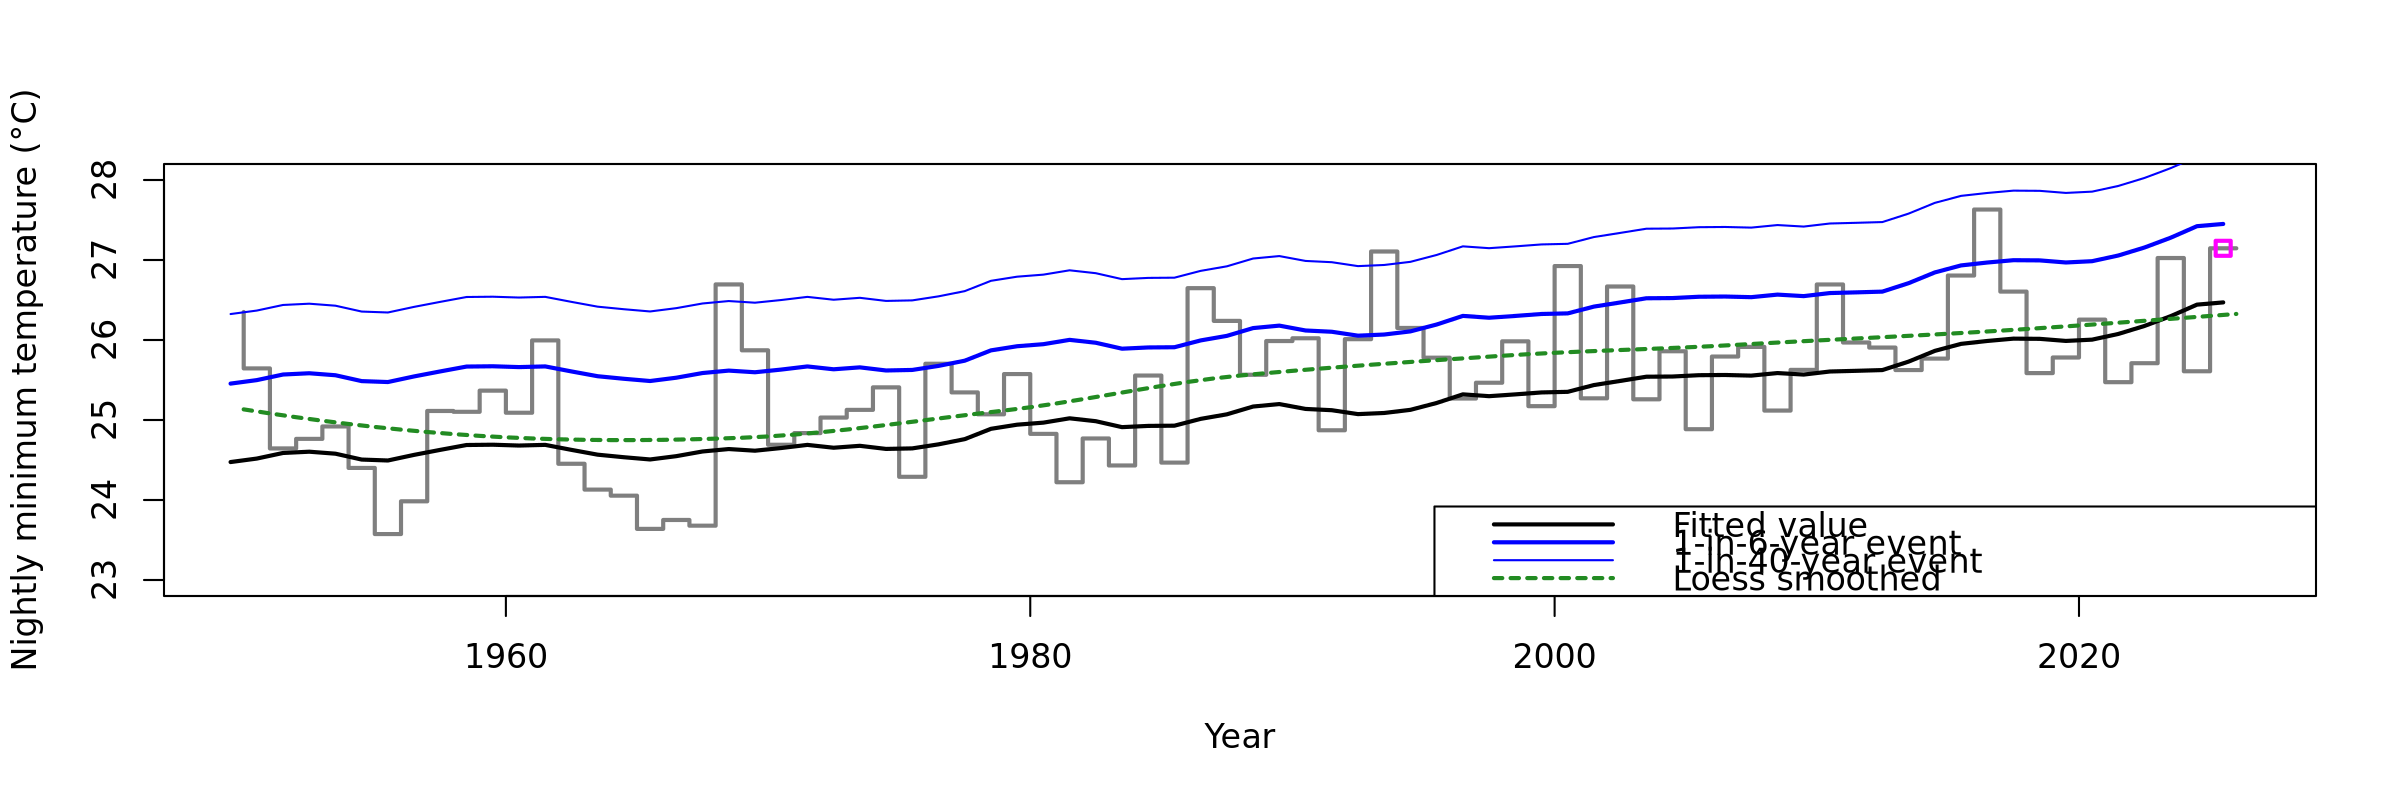

In [42]:
plot_trend(mdl, xlab = "Year", ylab = "Nightly minimum temperature (°C)", legend_pos = "bottomright")


## Compile results

In [54]:
varnm <- "tn1g-may"

In [55]:
res_obs <- t(sapply(list.files("res/", pattern = paste0("res-box_",varnm), full.names = T), function(fnm) {
    res <- read.csv(fnm, row.names = "X")
    unlist(sapply(rownames(res), function(cnm) setNames(res[cnm,], c("est", "lower", "upper")), simplify = F))
}))

write.csv(res_obs, paste0("res_",varnm,".csv"), row.names = T)

## Quick table

In [56]:
varnm <- "tn1g-may"

res_obs <- read.csv(paste0("res_",varnm,".csv"), row.names = "X")
(sapply(c("event_magnitude", "return_period", "PR", "dI_abs", "return_period_"), function(cnm) {
    df <- signif(res_obs[,grepl(cnm, colnames(res_obs))],3)
    apply(df,1,function(r) paste0(r[1], " (",r[2], ", ", r[3], ")"))
}))

,event_magnitude,return_period,PR,dI_abs,return_period_
res//res-box_tn1g-may_cpc_1950-onwards.csv,"24.6 (24.6, 24.6)","1.3 (1.05, 1.91)","148 (19.9, 5670)","2.62 (1.6, 3.81)","1.67 (1.13, 2.85)"
res//res-box_tn1g-may_era5_1950-onwards.csv,"24.8 (24.8, 24.8)","3.69 (2.14, 8.08)","1150 (199, 15800)","2.03 (1.53, 2.52)","5.58 (2.9, 15.1)"


---
# Initial analysis with Mecca point data

In [ ]:
ts_h <- read.csv("era5-land_t2m-hourly_39.8_21.4.csv")

ts_h$t2m <- ts_h$t2m - 273.15

ts_h$year <- as.integer(substr(ts_h$valid_time,1,4))
ts_h$month <- as.integer(substr(ts_h$valid_time,6,7))
ts_h$day <- as.integer(substr(ts_h$valid_time,9,10))

gmst <- read.table("gmst.txt", col.names = c("year", "gmst"))

cov_f <- gmst[gmst$year == 2026,"gmst",drop = F]
cov_cf <- cov_f - 1.3

# daily time series
ts_d <- aggregate(ts_h$t2m, by = list("day" = ts_h$day, "month" = ts_h$month, "year" = ts_h$year), "mean")

# Trend analysis - May mean temperatures

In [139]:
ts_may <- ts_d[ts_d$month == 5,c("year", "x")]
ts_may <- aggregate(ts_may$x, by = list("year" = ts_may$year), "mean")

In [140]:
df_may <- merge(gmst, ts_may)
df_may <- df_may[df_may$year <= 2025,] # because we only have part of May 2025

In [141]:
df_jja <- ts_d[ts_d$month %in% c(6,7,8),c("year", "x")]
df_jja <- aggregate(df_jja$x, by = list("year" = df_jja$year), "mean")
mean(df_jja[df_jja$year >= 1970 & df_jja$year <= 1990,"x"])

ev <- 32

[1] 32.22555

In [142]:
mdl_1950 <- fit_ns("norm", "shift", data = df_may, varnm = "x", covnm = "gmst", lower = F, ev = ev, ev_year = 2026)
mdl_1960 <- fit_ns("norm", "shift", data = df_may[df_may$year >= 1960,], varnm = "x", covnm = "gmst", lower = F, ev = ev, ev_year = 2026)
mdl_1970 <- fit_ns("norm", "shift", data = df_may[df_may$year >= 1970,], varnm = "x", covnm = "gmst", lower = F, ev = ev, ev_year = 2026)

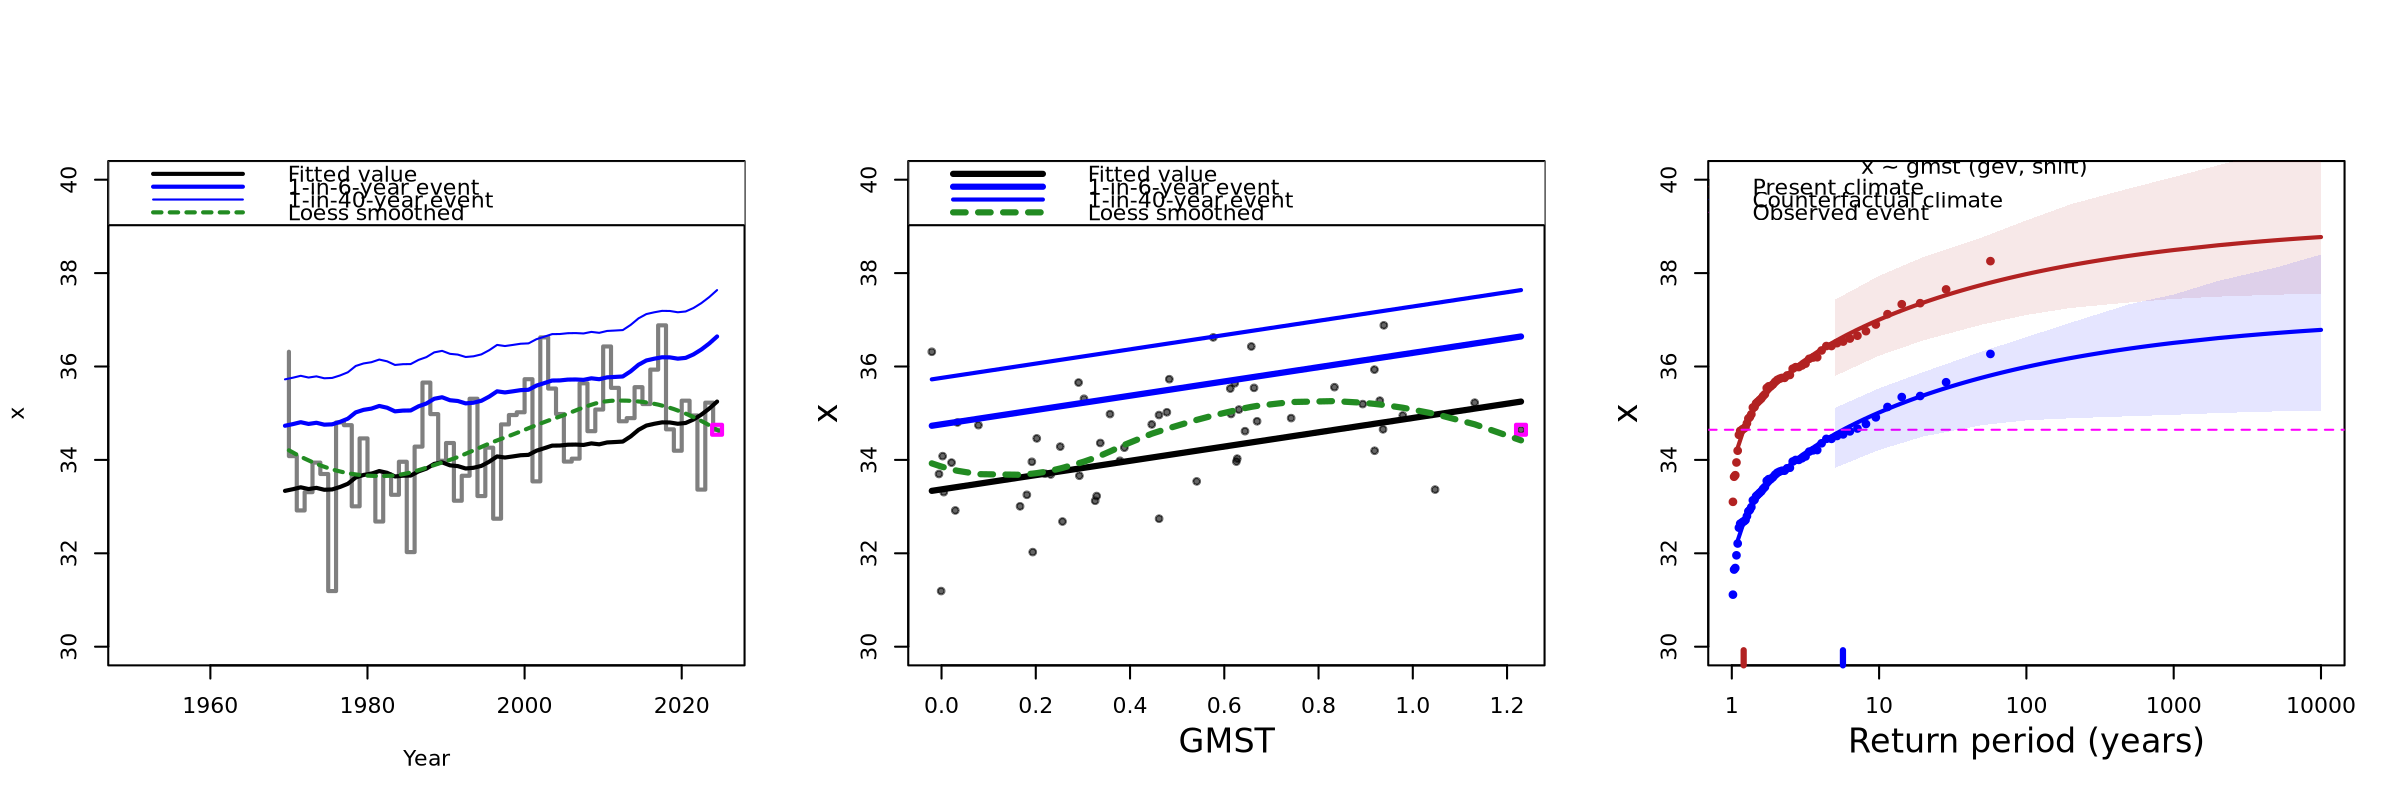

In [112]:
for (i in 1:3) {

    png(paste0("fig/trendplots_may-mean-temps_",ystart,"-onwards.png"), h = png_res, w = png_res * 3); {
        prep_window(c(1,3), oma = c(0,0,2,0))
        ylim <- c(30,36)
    
        ystart <- c(1950,1960,1970)[i]
        mdl <- get(paste0("mdl_",ystart))
    
        plot_trend(mdl, ylim = ylim, xlim = c(1950,2025))
        plot_covtrend(mdl, "gmst", ylim = ylim)
        plot_returnlevels(mdl, cov_f, cov_cf, ylim = ylim)
        mtext(paste0("Trend in May mean temps using ",ystart," onwards (ERA5-Land, Mecca grid cell)"), side = 3, outer = T)
    }; dev.off()
}

In [102]:
# bootstrap results (use event value of 32C)
for (i in 1:3) {
    ystart <- c(1950,1960,1970)[i]
    mdl <- get(paste0("mdl_",ystart))
    res_fnm <- paste0("res/res-mecca_may-mean-temps_",ystart,"-onwards.csv")
    if (file.exists(res_fnm)) next
    
    boot_res <- boot_ci(mdl, cov_f, cov_cf, ev = 32)
    write.csv(boot_res, res_fnm)
}

# Trend analysis - short-duration temperatures

In [143]:
tx1x_may <- ts_d[ts_d$month == 5,c("year", "x")]
tx1x_may <- aggregate(tx1x_may$x, by = list("year" = tx1x_may$year), "max")

In [144]:
df_may <- merge(gmst, tx1x_may)
df_may <- df_may[df_may$year <= 2025,] # because we only have part of May 2025

In [151]:
df_jja <- ts_d[ts_d$month %in% c(6,7,8),c("year", "x")]
df_jja <- aggregate(df_jja$x, by = list("year" = df_jja$year), "max")
mean(df_jja[df_jja$year >= 1970 & df_jja$year <= 1990,"x"])

ev <- 35

[1] 34.82869

In [146]:
mdl_1950 <- fit_ns("gev", "shift", data = df_may, varnm = "x", covnm = "gmst", lower = F, ev = ev, ev_year = 2026)
mdl_1960 <- fit_ns("gev", "shift", data = df_may[df_may$year >= 1960,], varnm = "x", covnm = "gmst", lower = F, ev = ev, ev_year = 2026)
mdl_1970 <- fit_ns("gev", "shift", data = df_may[df_may$year >= 1970,], varnm = "x", covnm = "gmst", lower = F, ev = ev, ev_year = 2026)

In [147]:
for (i in 1:3) {

    png(paste0("fig/trendplots_may-tx1x_",ystart,"-onwards.png"), h = png_res, w = png_res * 3); {
        prep_window(c(1,3), oma = c(0,0,2,0))
        ylim <- c(30,40)
    
        ystart <- c(1950,1960,1970)[i]
        mdl <- get(paste0("mdl_",ystart))
    
        plot_trend(mdl, ylim = ylim, xlim = c(1950,2025))
        plot_covtrend(mdl, "gmst", ylim = ylim)
        plot_returnlevels(mdl, cov_f, cov_cf, ylim = ylim)
        mtext(paste0("Trend in May one-day max temps using ",ystart," onwards (ERA5-Land, Mecca grid cell)"), side = 3, outer = T)
    }; dev.off()
}

In [148]:
# bootstrap results (use event value of 35C)
for (i in 1:3) {
    ystart <- c(1950,1960,1970)[i]
    mdl <- get(paste0("mdl_",ystart))
    res_fnm <- paste0("res/res-mecca_may-tx1x_",ystart,"-onwards.csv")
    if (file.exists(res_fnm)) next
    
    boot_res <- boot_ci(mdl, cov_f, cov_cf, ev = ev)
    write.csv(boot_res, res_fnm)
}

## Compile results

In [53]:
varnm <- "tx1x"
res_obs <- t(sapply(list.files("res", pattern = paste0("res-box_",varnm), full.names = T), function(fnm) {
    res <- read.csv(fnm, row.names = "X")
    unlist(sapply(rownames(res), function(cnm) setNames(res[cnm,], c("est", "lower", "upper")), simplify = F))
}))

write.csv(res_obs, paste0("res-era5land_may-",varnm,".csv"), row.names = T)

In [63]:
res_obs <- read.csv("res-era5land_may-mean.csv", row.names = "X")
t1 <- sapply(c("dI_abs", "return_period", "PR"), function(cnm) {
    df <- signif(res_obs[,grepl(cnm, colnames(res_obs))],3)
    apply(df,1,function(r) paste0(r[1], " (",r[2], ", ", r[3], ")"))
})
t1

,dI_abs,return_period,PR
res/res-mecca_may-mean-temps_1950-onwards.csv,"2.86 (2.27, 3.53)","1.07 (1.01, 1.18)","56.9 (24.6, 187)"
res/res-mecca_may-mean-temps_1960-onwards.csv,"2.51 (1.89, 3.23)","1.08 (1.02, 1.22)","43 (17.1, 180)"
res/res-mecca_may-mean-temps_1970-onwards.csv,"2.01 (1.43, 2.65)","1.12 (1.03, 1.31)","25.6 (9.39, 171)"


In [64]:
res_obs <- read.csv("res-era5land_may-tx1x.csv", row.names = "X")
t2 <- sapply(c("dI_abs", "return_period", "PR"), function(cnm) {
    df <- signif(res_obs[,grepl(cnm, colnames(res_obs))],3)
    apply(df,1,function(r) paste0(r[1], " (",r[2], ", ", r[3], ")"))
})
t2

,dI_abs,return_period,PR
res/res-mecca_may-tx1x_1950-onwards.csv,"2.41 (1.46, 3.45)","1.29 (1.06, 1.7)","10 (3.95, 96)"
res/res-mecca_may-tx1x_1960-onwards.csv,"2.18 (1.25, 3.23)","1.32 (1.06, 1.8)","8.48 (3.01, 98)"
res/res-mecca_may-tx1x_1970-onwards.csv,"1.99 (0.947, 3.42)","1.37 (1.05, 2.04)","7.1 (2.61, 1590)"


# Quantile regression

In [57]:
tau <- c(0.01,0.05,seq(0.05,0.95,0.05), 0.975, 0.99)

ts_d <- aggregate(ts_h$t2m, by = list("day" = ts_h$day, "month" = ts_h$month, "year" = ts_h$year), "mean")
df <- merge(gmst, ts_d)

In [58]:
qfit <- rq(x ~ gmst, data = df, tau = tau)

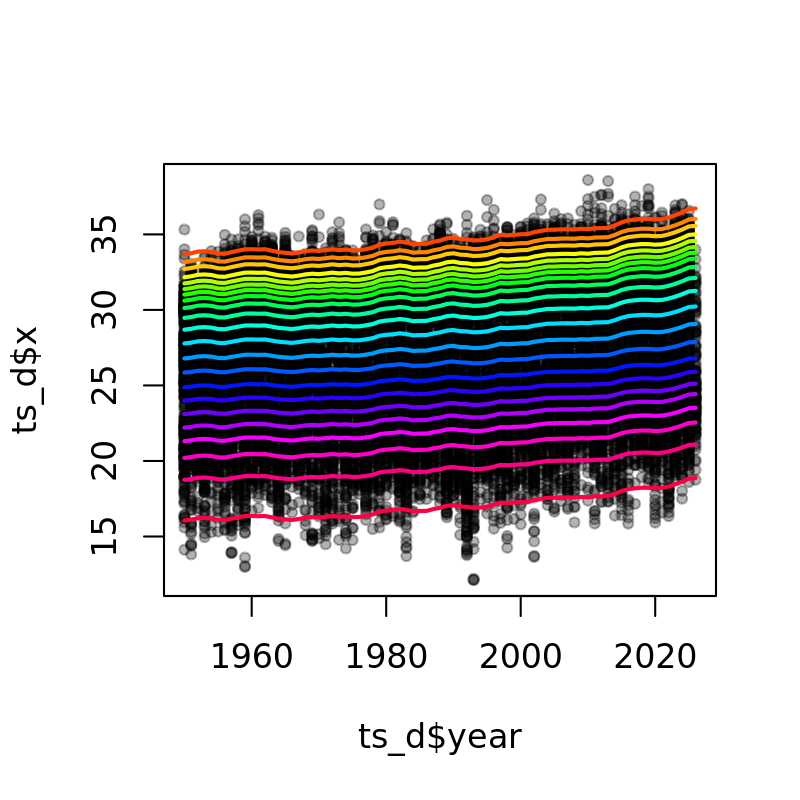

In [61]:
prep_window()
plot(ts_d$year, ts_d$x, col = adjustcolor("black", 0.3), pch = 20)

matplot(ts_d$year, fitted(qfit), type = "l", col = rev(rainbow(length(tau))), add = T, lty = 1, lwd = 2)